<a href="https://colab.research.google.com/github/saskiamatso/Projeto_Skincare_Analise_Sephora/blob/main/Projeto_Skincare_Analise_Sephora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 147M/147M [00:00<00:00, 177MB/s]

Extracting files...


Arquivos baixados: ['reviews_250-500.csv', 'reviews_0-250.csv', 'reviews_1250-end.csv', 'reviews_750-1250.csv', 'product_info.csv', 'reviews_500-750.csv']

--- Tabela carregada com sucesso ---


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


/tmp/ipykernel_21387/688978385.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=marcas_caras.values, y=marcas_caras.index, palette='magma')


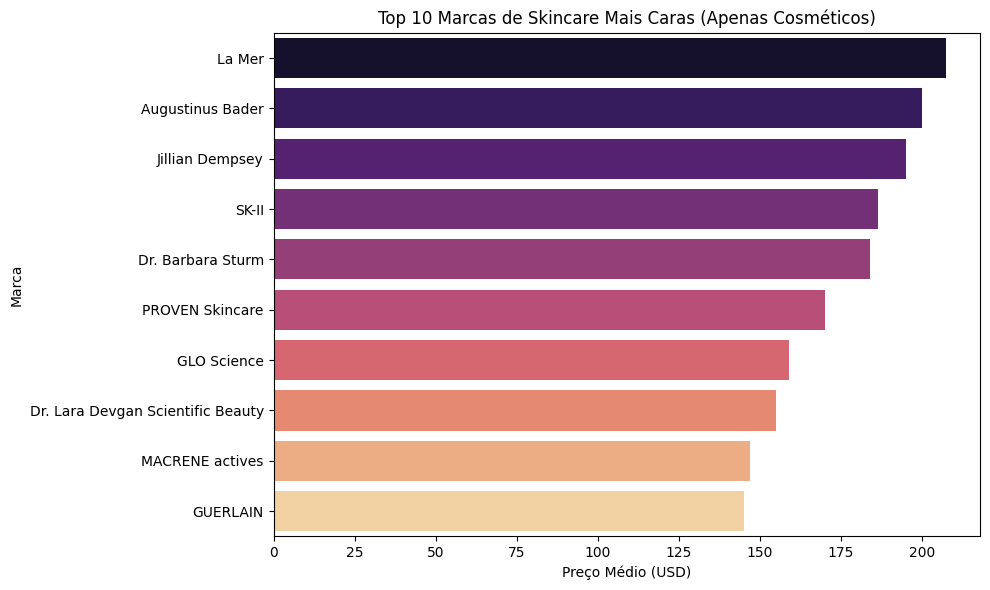

In [ ]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Baixar dataset
path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")

# 2. Verificar arquivos disponíveis
arquivos = os.listdir(path)
print("Arquivos baixados:", arquivos)

# 3. Carregar arquivo de produtos
arquivo_alvo = 'product_info.csv'

if arquivo_alvo not in arquivos:
    print(f"Erro: '{arquivo_alvo}' não encontrado.")
else:
    caminho_completo = os.path.join(path, arquivo_alvo)
    df_produtos = pd.read_csv(caminho_completo)
    print("\n--- Tabela carregada com sucesso ---")
    display(df_produtos.head())

    # 4. Filtrar apenas Skincare, excluindo aparelhos
    df_skincare = df_produtos[
        (df_produtos['primary_category'] == 'Skincare') &
        (~df_produtos['secondary_category'].str.contains('Tools|Devices', na=False, case=False))
    ].copy()

    # 5. Top 10 marcas mais caras
    marcas_caras = (
        df_skincare
        .groupby('brand_name')['price_usd']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    # 6. Gráfico
    plt.figure(figsize=(10, 6))
    sns.barplot(x=marcas_caras.values, y=marcas_caras.index, palette='magma')
    plt.title('Top 10 Marcas de Skincare Mais Caras (Apenas Cosméticos)')
    plt.xlabel('Preço Médio (USD)')
    plt.ylabel('Marca')
    plt.tight_layout()
    plt.show()